In [1]:
!pip install opencv-python-headless grad-cam --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 100.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import random
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,            
                              confusion_matrix,               
                              roc_curve, auc,                   
                              ConfusionMatrixDisplay)           
from sklearn.preprocessing import label_binarize 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models,regularizers 
from tensorflow.keras.preprocessing.image import (             
    ImageDataGenerator,                                       
    img_to_array, load_img)
from tensorflow.keras.callbacks import (EarlyStopping,        
                                         ModelCheckpoint,       
                                         ReduceLROnPlateau)    
from tensorflow.keras.utils import to_categorical             
from tensorflow.keras.applications import MobileNetV2        
SEED = 42                                  
np.random.seed(SEED)                      
random.seed(SEED)                           
tf.random.set_seed(SEED)    
print(f'✅ TensorFlow version: {tf.__version__}')   
print(f'✅ Keras version: {keras.__version__}')     
print(f'✅ GPU Available: {len(tf.config.list_physical_devices("GPU")) > 0}')

✅ TensorFlow version: 2.20.0
✅ Keras version: 3.13.2
✅ GPU Available: True


In [3]:
DATASET_PATH ='/kaggle/input/datasets/vrajesh0sharma7/cat-vs-dog-classification/dogs_vs_cats/train'
MODEL_SAVE_PATH = 'kaggle/working/best_model.keras'

IMG_SIZE = 150
IMG_SIZE_RGB = 150
NUM_CHANNELS = 3
NUM_CLASSES = 2

BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 1e-3
VAL_SPLIT = 0.2
TEST_SPLIT = 0.1

ANIMAL_LABEL={
    0 : 'Cat',
    1 : 'Dog'
    
}
    
CLASS_NAMES = list(ANIMAL_LABEL.values())

sns.set_style('whitegrid')          
plt.rcParams['figure.dpi'] = 100  

print('✅ Configuration set successfully!')
print(f'   Image size  : {IMG_SIZE}x{IMG_SIZE}x{NUM_CHANNELS}')
print(f'   Classes     : {NUM_CLASSES} → {CLASS_NAMES}')
print(f'   Batch size  : {BATCH_SIZE}')
print(f'   Max epochs  : {EPOCHS}')

✅ Configuration set successfully!
   Image size  : 150x150x3
   Classes     : 2 → ['Cat', 'Dog']
   Batch size  : 64
   Max epochs  : 50


In [4]:
datagen = ImageDataGenerator(
    rescale        = 1./255,
    validation_split = VAL_SPLIT   # 0.2
)


train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size = (IMG_SIZE, IMG_SIZE),   
    batch_size  = BATCH_SIZE,             
    class_mode  = 'binary',
    subset      = 'training',
    seed        = SEED                   
)


val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size = (IMG_SIZE, IMG_SIZE),   
    batch_size  = BATCH_SIZE,             
    class_mode  = 'binary',
    subset      = 'validation',
    seed        = SEED                    
)

print(f'✅ Training   data : {train_data.samples} images')
print(f'✅ Validation data : {val_data.samples} images')
print(f'   Image size      : {IMG_SIZE}x{IMG_SIZE}x{NUM_CHANNELS}')
print(f'   Batch size      : {BATCH_SIZE}')
print(f'   Classes         : {train_data.class_indices}')

Found 16000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.
✅ Training   data : 16000 images
✅ Validation data : 4000 images
   Image size      : 150x150x3
   Batch size      : 64
   Classes         : {'cats': 0, 'dogs': 1}


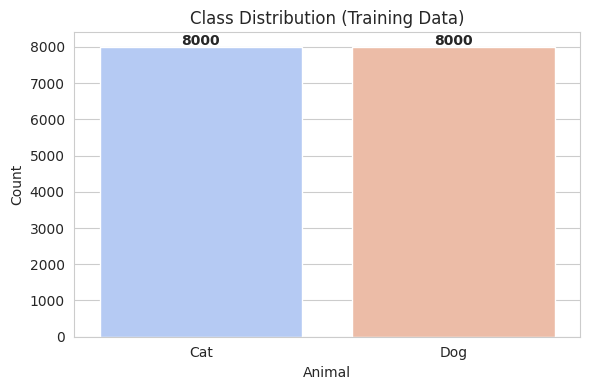

🐱 Cats : 8000
🐶 Dogs : 8000
⚖️  Balanced: True


In [5]:
labels = train_data.classes
class_counts = pd.Series(labels).value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.barplot(x=CLASS_NAMES, y=class_counts.values, palette='coolwarm')
plt.title('Class Distribution (Training Data)')
plt.xlabel('Animal')
plt.ylabel('Count')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'🐱 Cats : {class_counts[0]}')
print(f'🐶 Dogs : {class_counts[1]}')
print(f'⚖️  Balanced: {class_counts[0] == class_counts[1]}')

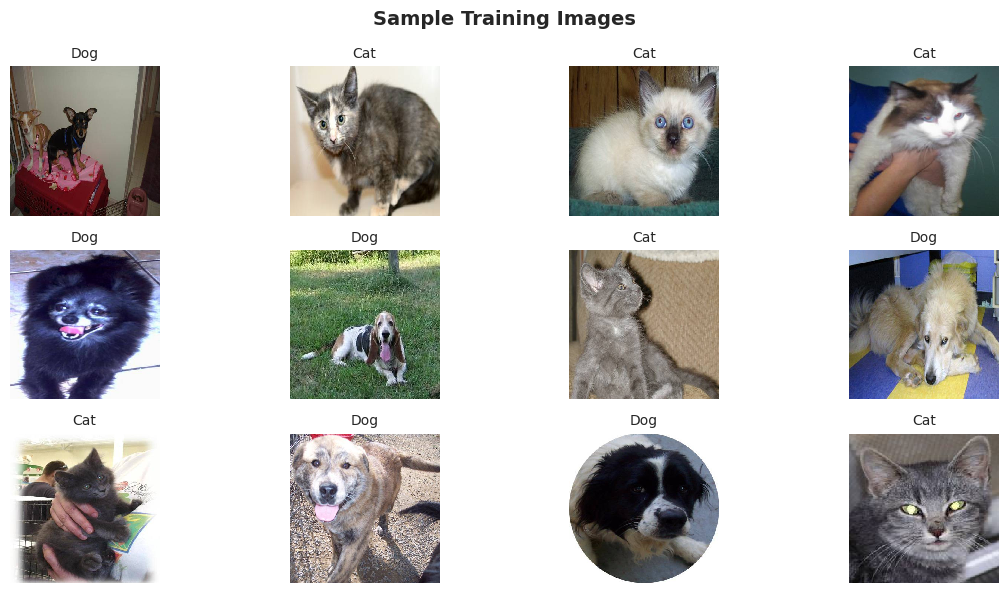

In [6]:
images, labels = next(train_data)   

plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(images[i])
    label = ANIMAL_LABEL[int(labels[i])]
    plt.title(label, fontsize=10)
    plt.axis('off')
plt.suptitle('Sample Training Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

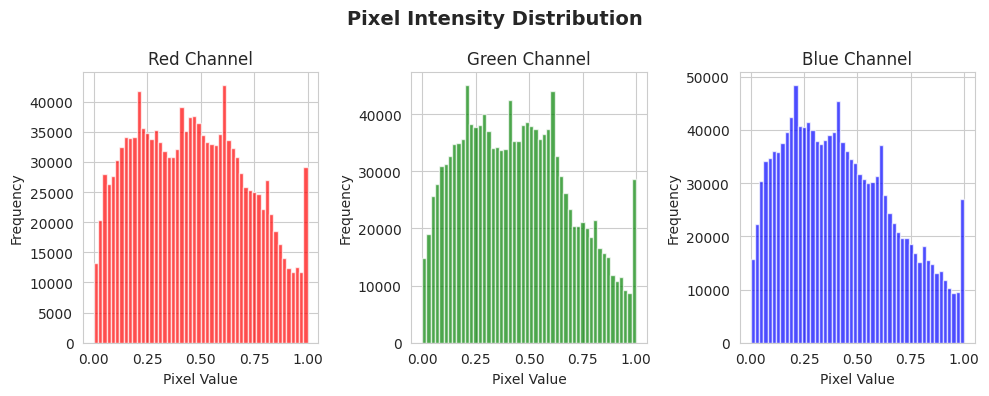

In [7]:
plt.figure(figsize=(10, 4))
colors = ['red', 'green', 'blue']
channel_names = ['Red', 'Green', 'Blue']

for i, (color, name) in enumerate(zip(colors, channel_names)):
    plt.subplot(1, 3, i+1)
    plt.hist(images[:, :, :, i].ravel(), bins=50, color=color, alpha=0.7)
    plt.title(f'{name} Channel')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')

plt.suptitle('Pixel Intensity Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

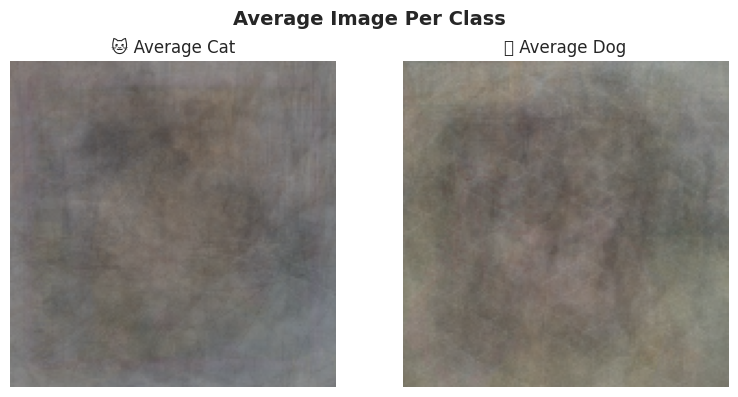

In [8]:
cat_imgs = images[labels == 0]
dog_imgs = images[labels == 1]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(cat_imgs.mean(axis=0))
axes[0].set_title('🐱 Average Cat')
axes[0].axis('off')

axes[1].imshow(dog_imgs.mean(axis=0))
axes[1].set_title('🐶 Average Dog')
axes[1].axis('off')

plt.suptitle('Average Image Per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
def build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, NUM_CHANNELS)):
    
    model = models.Sequential([

        # ── Block 1 ────────────────────────────────────────
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),
        
        # ── Block 2 ───────────────────────────────────────────
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),
        
        # ── Block 3 ───────────────────────────────────────────
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),
        
        # ── Classifier Head ───────────────────────────────────
        layers.Flatten(),
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')   
    ])
    
    return model

cnn_model = build_custom_cnn()
cnn_model.summary()

I0000 00:00:1783592807.018918      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,906,273 (41.60 MB)

 Trainable params: 10,905,313 (41.60 MB)

 Non-trainable params: 960 (3.75 KB)

In [10]:
cnn_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)
print('✅ Model compiled successfully!')

✅ Model compiled successfully!


In [11]:
callbacks = [
    EarlyStopping(
        monitor   = 'val_loss',
        patience  = 5,         
        restore_best_weights = True,
        verbose   = 1
    ),
    ModelCheckpoint(
        filepath  = MODEL_SAVE_PATH,
        monitor   = 'val_accuracy',
        save_best_only = True,
        verbose   = 1
    ),
    ReduceLROnPlateau(
        monitor   = 'val_loss',
        factor    = 0.5,       
        patience  = 3,
        min_lr    = 1e-7,
        verbose   = 1
    )
]
print('✅ Callbacks ready!')

✅ Callbacks ready!


In [12]:
print('🚀 Training Custom CNN...')
cnn_history = cnn_model.fit(
    train_data,
    epochs          = EPOCHS,
    validation_data = val_data,
    callbacks       = callbacks,
    verbose         = 1
)
print('✅ Training complete!')

🚀 Training Custom CNN...
Epoch 1/50
  2/250 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.5039 - loss: 1.6193   

I0000 00:00:1783592824.698056     100 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.6289 - loss: 1.3178
Epoch 1: val_accuracy improved from None to 0.50000, saving model to kaggle/working/best_model.keras

Epoch 1: finished saving model to kaggle/working/best_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 123s 431ms/step - accuracy: 0.6776 - loss: 1.1110 - val_accuracy: 0.5000 - val_loss: 1.0207 - learning_rate: 0.0010
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.7551 - loss: 0.7375
Epoch 2: val_accuracy improved from 0.50000 to 0.59175, saving model to kaggle/working/best_model.keras

Epoch 2: finished saving model to kaggle/working/best_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 48s 193ms/step - accuracy: 0.7668 - loss: 0.6911 - val_accuracy: 0.5918 - val_loss: 0.8226 - learning_rate: 0.0010
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8070 - loss: 0.5922
Epoch 3: val_accuracy improved from 0.59175 to 0.78550, saving model to kaggle/working/best_model.keras

Epoch 3: finis

In [13]:
val_datagen = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = VAL_SPLIT
)

val_data_eval = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    subset      = 'validation',
    seed        = SEED,
    shuffle     = True
)


val_data_eval.reset()
all_images, all_labels = [], []

for images, labels in val_data_eval:
    all_images.append(images)
    all_labels.append(labels)
    if len(all_labels) * BATCH_SIZE >= val_data_eval.samples:
        break

all_images = np.concatenate(all_images, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

y_pred_prob = cnn_model.predict(all_images, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = all_labels.astype(int)

print(f'✅ Predictions : {len(y_pred)}')
print(f'✅ True labels : {len(y_true)}')

Found 4000 images belonging to 2 classes.
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
✅ Predictions : 4000
✅ True labels : 4000


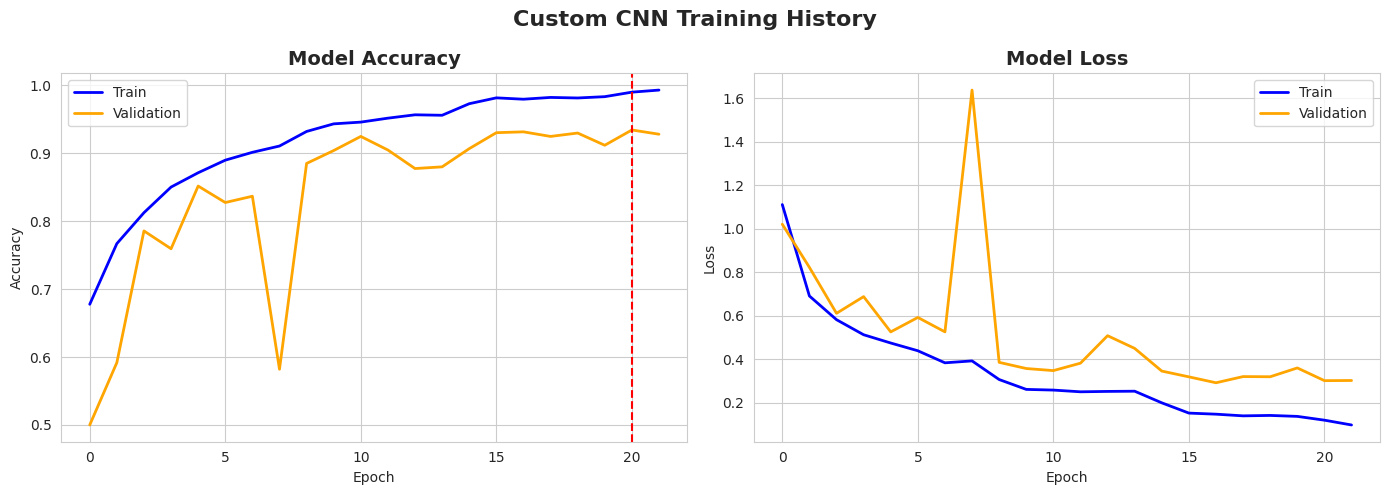

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history.history['accuracy'], 
             label='Train', color='blue', linewidth=2)
axes[0].plot(cnn_history.history['val_accuracy'], 
             label='Validation', color='orange', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].axvline(x=20, color='red', linestyle='--', 
                label='Best Epoch')  # epoch 21


axes[1].plot(cnn_history.history['loss'], 
             label='Train', color='blue', linewidth=2)
axes[1].plot(cnn_history.history['val_loss'], 
             label='Validation', color='orange', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Custom CNN Training History', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

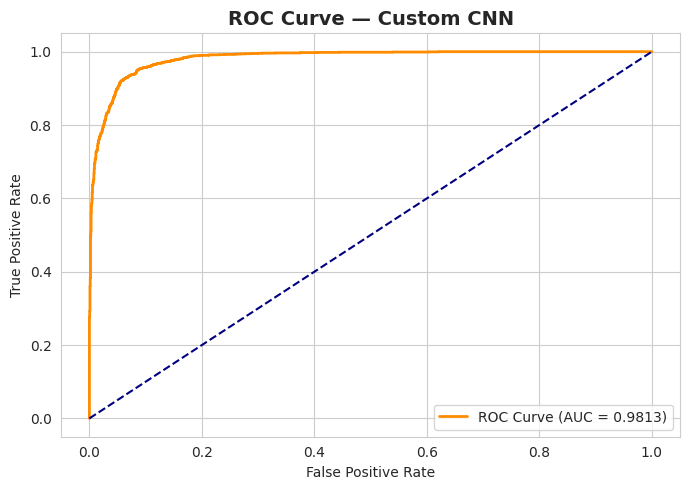

In [15]:
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', linewidth=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Custom CNN', 
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

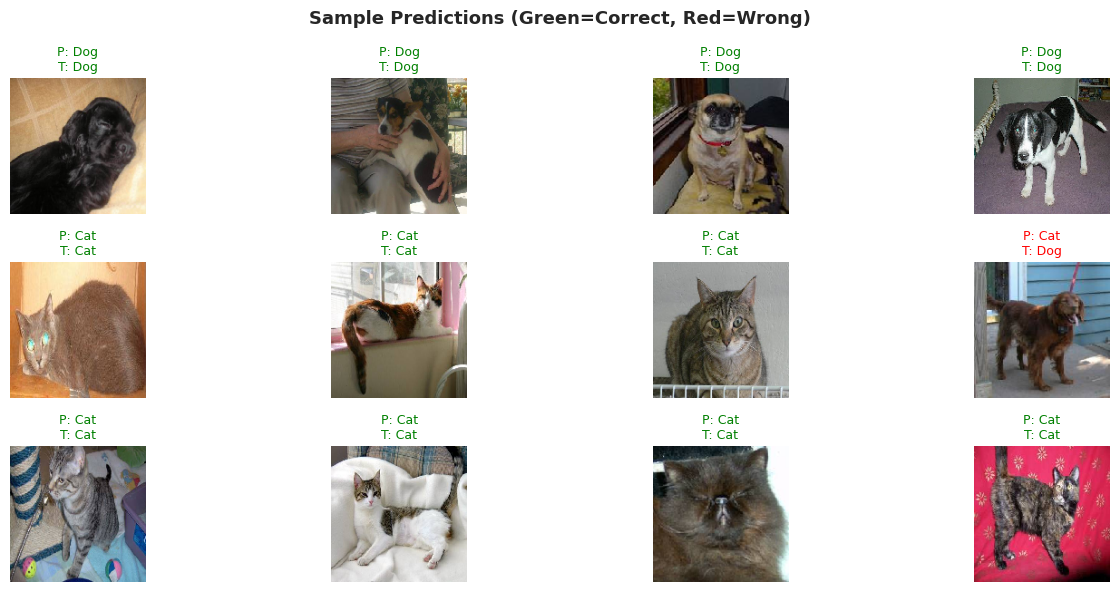

In [16]:
val_data.reset()
images, labels = next(val_data)

plt.figure(figsize=(14, 6))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(images[i])
    
    pred_prob = cnn_model.predict(images[i:i+1], verbose=0)[0][0]
    pred_label = ANIMAL_LABEL[int(pred_prob > 0.5)]
    true_label = ANIMAL_LABEL[int(labels[i])]
    
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f'P: {pred_label}\nT: {true_label}', 
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

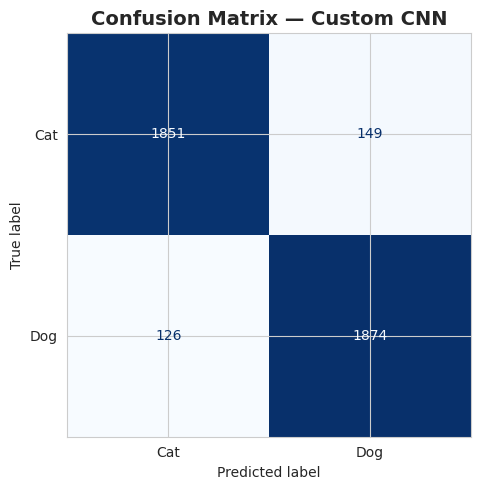

In [17]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix — Custom CNN',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
print('📊 Classification Report — Custom CNN')
print('='*45)
print(classification_report(y_true, y_pred, 
                             target_names=CLASS_NAMES))

📊 Classification Report — Custom CNN
              precision    recall  f1-score   support

         Cat       0.94      0.93      0.93      2000
         Dog       0.93      0.94      0.93      2000

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000



In [19]:
def build_mobilenet(input_shape=(IMG_SIZE, IMG_SIZE, NUM_CHANNELS)):
    
    base_model = MobileNetV2(
        input_shape = input_shape,
        include_top = False,      
        weights     = 'imagenet'  
    )
    
    base_model.trainable = False
    
    model = models.Sequential([
        base_model,
        
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model

mobilenet_model = build_mobilenet()
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,591,297 (9.89 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [20]:
mobilenet_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)
print('✅ MobileNetV2 compiled!')

✅ MobileNetV2 compiled!


In [21]:
mobilenet_callbacks = [
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ModelCheckpoint(
        filepath       = 'kaggle/working/best_mobilenet.keras',
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-7,
        verbose  = 1
    )
]
print('✅ Callbacks ready!')

✅ Callbacks ready!


In [22]:
print('🚀 Training MobileNetV2 Phase 1 (frozen base)...')
mobilenet_history = mobilenet_model.fit(
    train_data,
    epochs          = EPOCHS,
    validation_data = val_data,
    callbacks       = mobilenet_callbacks,
    verbose         = 1
)
print('✅ Phase 1 complete!')

🚀 Training MobileNetV2 Phase 1 (frozen base)...
Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9344 - loss: 0.5595
Epoch 1: val_accuracy improved from None to 0.96025, saving model to kaggle/working/best_mobilenet.keras

Epoch 1: finished saving model to kaggle/working/best_mobilenet.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 72s 237ms/step - accuracy: 0.9484 - loss: 0.4742 - val_accuracy: 0.9603 - val_loss: 0.3494 - learning_rate: 0.0010
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9674 - loss: 0.3098
Epoch 2: val_accuracy improved from 0.96025 to 0.96275, saving model to kaggle/working/best_mobilenet.keras

Epoch 2: finished saving model to kaggle/working/best_mobilenet.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 48s 190ms/step - accuracy: 0.9661 - loss: 0.2888 - val_accuracy: 0.9628 - val_loss: 0.2491 - learning_rate: 0.0010
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9735 - loss: 0.2145
Epoch 3: val_accuracy did not improve from 0.

In [23]:
from tensorflow.keras.models import load_model

mobilenet_model = load_model('kaggle/working/best_mobilenet.keras')
print('✅ Best Phase 1 model loaded!')

base_model = mobilenet_model.layers[0]
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

mobilenet_callbacks_ft = [
    EarlyStopping(
        monitor              = 'val_accuracy', 
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ModelCheckpoint(
        filepath        = 'kaggle/working/best_mobilenet.keras',
        monitor         = 'val_accuracy',
        save_best_only  = True,
        verbose         = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-7,
        verbose  = 1
    )
]

print('🚀 Fine tuning Phase 2...')
mobilenet_history_ft = mobilenet_model.fit(
    train_data,
    epochs          = 20,
    validation_data = val_data,
    callbacks       = mobilenet_callbacks_ft,
    verbose         = 1
)
print('✅ Fine tuning complete!')

✅ Best Phase 1 model loaded!
🚀 Fine tuning Phase 2...
Epoch 1/20


2026-07-09 11:25:19.738457: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-09 11:25:19.938580: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.9467 - loss: 0.1754
Epoch 1: val_accuracy improved from None to 0.95625, saving model to kaggle/working/best_mobilenet.keras

Epoch 1: finished saving model to kaggle/working/best_mobilenet.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 69s 211ms/step - accuracy: 0.9521 - loss: 0.1633 - val_accuracy: 0.9563 - val_loss: 0.1726 - learning_rate: 1.0000e-05
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9684 - loss: 0.1243
Epoch 2: val_accuracy improved from 0.95625 to 0.96100, saving model to kaggle/working/best_mobilenet.keras

Epoch 2: finished saving model to kaggle/working/best_mobilenet.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 48s 190ms/step - accuracy: 0.9689 - loss: 0.1233 - val_accuracy: 0.9610 - val_loss: 0.1650 - learning_rate: 1.0000e-05
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9778 - loss: 0.1058
Epoch 3: val_accuracy improved from 0.96100 to 0.96500, saving model to kaggle/working/best_mobi

In [24]:
val_data_eval.reset()
all_images, all_labels = [], []

for images, labels in val_data_eval:
    all_images.append(images)
    all_labels.append(labels)
    if len(all_labels) * BATCH_SIZE >= val_data_eval.samples:
        break

all_images = np.concatenate(all_images, axis=0)
all_labels = np.concatenate(all_labels, axis=0)


y_pred_prob_mb = mobilenet_model.predict(all_images, verbose=1)
y_pred_mb = (y_pred_prob_mb > 0.5).astype(int).flatten()
y_true_mb = all_labels.astype(int)

print(f'✅ Predictions : {len(y_pred_mb)}')
print(f'✅ True labels : {len(y_true_mb)}')

125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step
✅ Predictions : 4000
✅ True labels : 4000


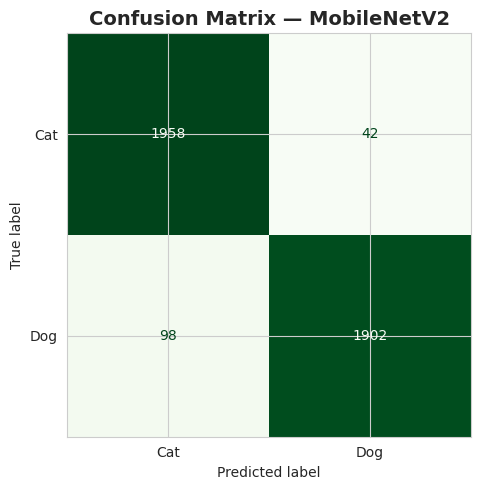

In [25]:
cm_mb = confusion_matrix(y_true_mb, y_pred_mb)
disp_mb = ConfusionMatrixDisplay(confusion_matrix=cm_mb,
                                  display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(6, 5))
disp_mb.plot(ax=ax, colorbar=False, cmap='Greens')
plt.title('Confusion Matrix — MobileNetV2',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
print('📊 Classification Report — MobileNetV2')
print('='*45)
print(classification_report(y_true_mb, y_pred_mb,
                             target_names=CLASS_NAMES))

📊 Classification Report — MobileNetV2
              precision    recall  f1-score   support

         Cat       0.95      0.98      0.97      2000
         Dog       0.98      0.95      0.96      2000

    accuracy                           0.96      4000
   macro avg       0.97      0.96      0.96      4000
weighted avg       0.97      0.96      0.96      4000



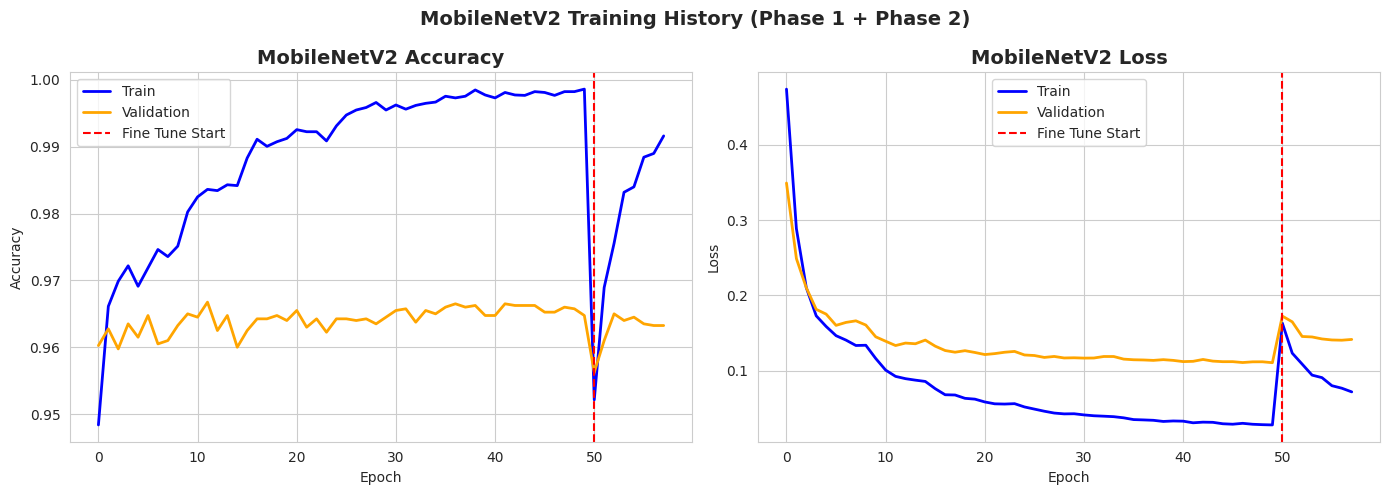

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

acc    = mobilenet_history.history['accuracy'] + \
         mobilenet_history_ft.history['accuracy']
val_acc= mobilenet_history.history['val_accuracy'] + \
         mobilenet_history_ft.history['val_accuracy']
loss   = mobilenet_history.history['loss'] + \
         mobilenet_history_ft.history['loss']
val_loss=mobilenet_history.history['val_loss'] + \
         mobilenet_history_ft.history['val_loss']

phase_split = len(mobilenet_history.history['accuracy'])


axes[0].plot(acc,     label='Train',      color='blue',   linewidth=2)
axes[0].plot(val_acc, label='Validation', color='orange', linewidth=2)
axes[0].axvline(x=phase_split, color='red', linestyle='--',
                label='Fine Tune Start')
axes[0].set_title('MobileNetV2 Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()


axes[1].plot(loss,     label='Train',      color='blue',   linewidth=2)
axes[1].plot(val_loss, label='Validation', color='orange', linewidth=2)
axes[1].axvline(x=phase_split, color='red', linestyle='--',
                label='Fine Tune Start')
axes[1].set_title('MobileNetV2 Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('MobileNetV2 Training History (Phase 1 + Phase 2)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

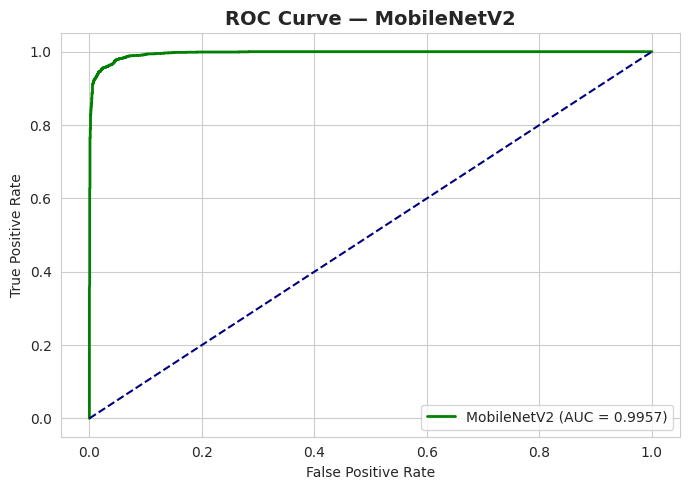

In [28]:

fpr_mb, tpr_mb, _ = roc_curve(y_true_mb, y_pred_prob_mb)
roc_auc_mb = auc(fpr_mb, tpr_mb)

plt.figure(figsize=(7, 5))
plt.plot(fpr_mb, tpr_mb, color='green', linewidth=2,
         label=f'MobileNetV2 (AUC = {roc_auc_mb:.4f})')
plt.plot([0,1], [0,1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — MobileNetV2',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

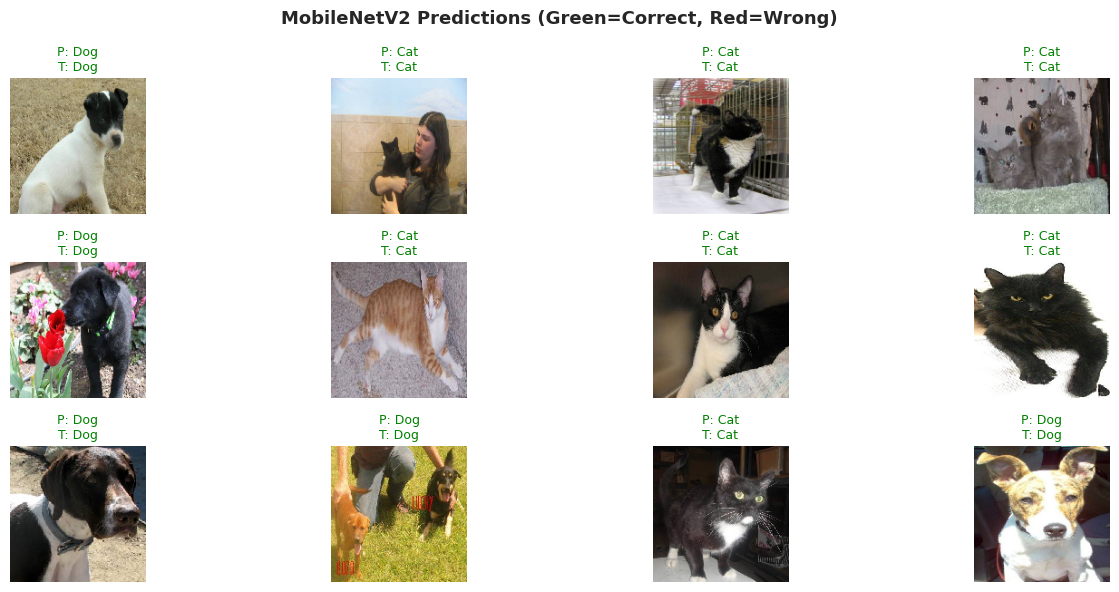

In [29]:
plt.figure(figsize=(14, 6))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(all_images[i])

    pred_prob  = mobilenet_model.predict(
                    all_images[i:i+1], verbose=0)[0][0]
    pred_label = ANIMAL_LABEL[int(pred_prob > 0.5)]
    true_label = ANIMAL_LABEL[int(y_true_mb[i])]

    color = 'green' if pred_label == true_label else 'red'
    plt.title(f'P: {pred_label}\nT: {true_label}',
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('MobileNetV2 Predictions (Green=Correct, Red=Wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**SIDE BY SIDE COMPARISIONN**

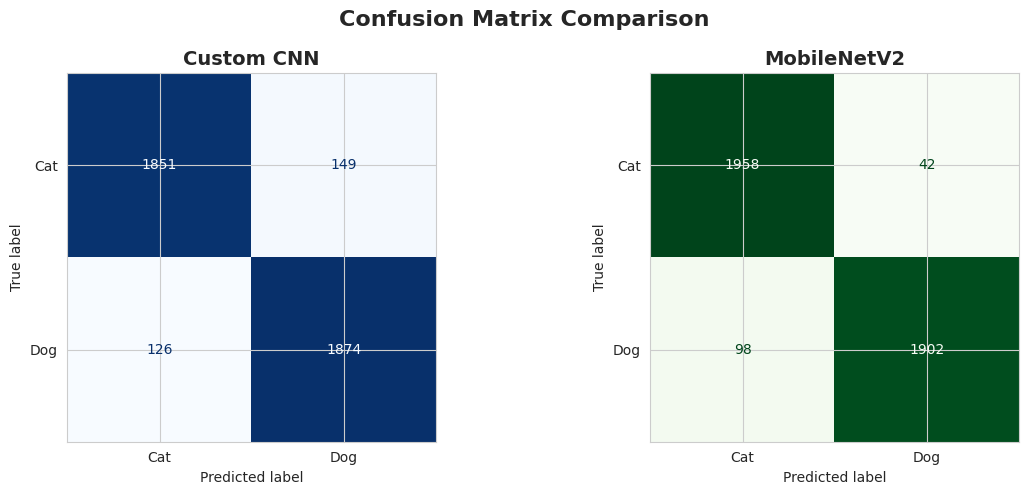

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_cnn = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm_cnn, display_labels=CLASS_NAMES)\
    .plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Custom CNN', fontsize=14, fontweight='bold')

cm_mb = confusion_matrix(y_true_mb, y_pred_mb)
ConfusionMatrixDisplay(cm_mb, display_labels=CLASS_NAMES)\
    .plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('MobileNetV2', fontsize=14, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

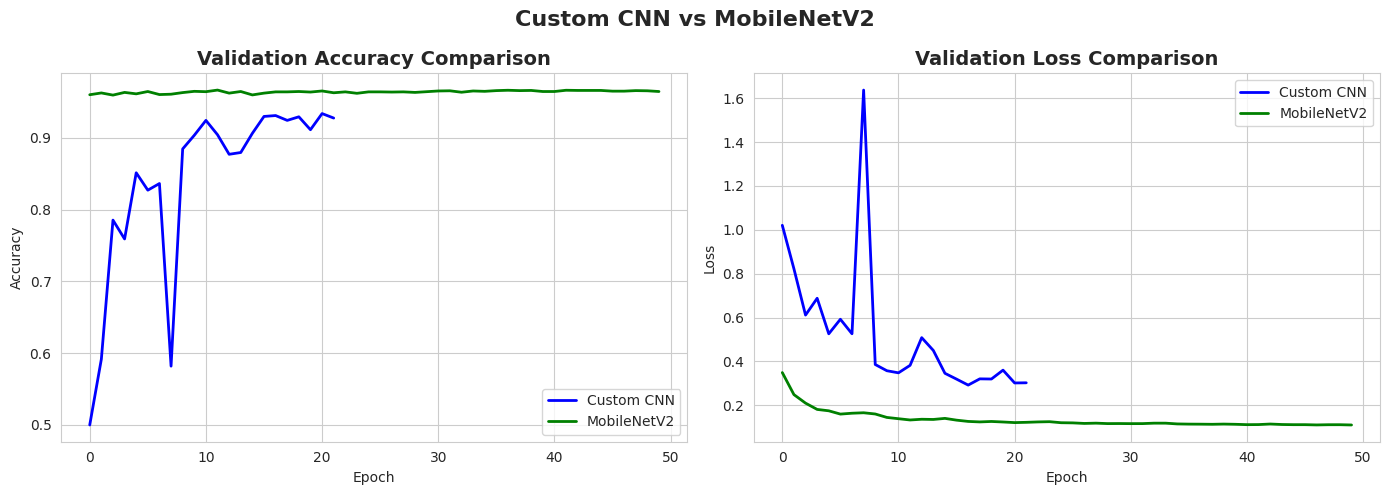

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history.history['val_accuracy'],
             label='Custom CNN', color='blue', linewidth=2)
axes[0].plot(mobilenet_history.history['val_accuracy'],
             label='MobileNetV2', color='green', linewidth=2)
axes[0].set_title('Validation Accuracy Comparison',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(cnn_history.history['val_loss'],
             label='Custom CNN', color='blue', linewidth=2)
axes[1].plot(mobilenet_history.history['val_loss'],
             label='MobileNetV2', color='green', linewidth=2)
axes[1].set_title('Validation Loss Comparison',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Custom CNN vs MobileNetV2',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

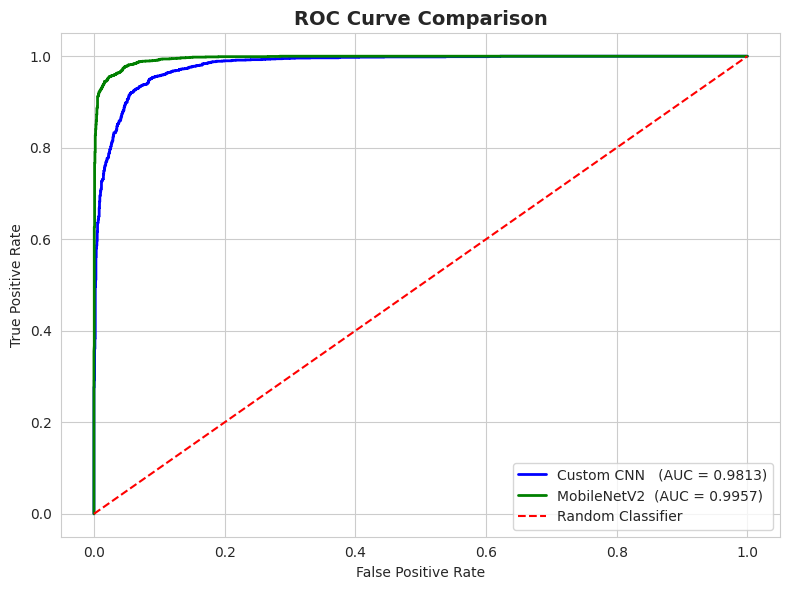

In [32]:
fpr_cnn, tpr_cnn, _ = roc_curve(y_true, y_pred_prob)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)

fpr_mb, tpr_mb, _ = roc_curve(y_true_mb, y_pred_prob_mb)
roc_auc_mb = auc(fpr_mb, tpr_mb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_cnn, tpr_cnn, color='blue', linewidth=2,
         label=f'Custom CNN   (AUC = {roc_auc_cnn:.4f})')
plt.plot(fpr_mb,  tpr_mb,  color='green', linewidth=2,
         label=f'MobileNetV2  (AUC = {roc_auc_mb:.4f})')
plt.plot([0,1], [0,1], color='red', linestyle='--',
         label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import accuracy_score, f1_score

cnn_acc = accuracy_score(y_true, y_pred)
mb_acc  = accuracy_score(y_true_mb, y_pred_mb)
cnn_f1  = f1_score(y_true, y_pred)
mb_f1   = f1_score(y_true_mb, y_pred_mb)

summary = pd.DataFrame({
    'Model'       : ['Custom CNN', 'MobileNetV2'],
    'Accuracy'    : [f'{cnn_acc:.4f}', f'{mb_acc:.4f}'],
    'F1 Score'    : [f'{cnn_f1:.4f}', f'{mb_f1:.4f}'],
    'AUC'         : [f'{roc_auc_cnn:.4f}', f'{roc_auc_mb:.4f}'],
    'Parameters'  : [f'{cnn_model.count_params():,}',
                     f'{mobilenet_model.count_params():,}'],
    'Winner'      : ['', '🏆']
})

print('='*65)
print('         FINAL MODEL COMPARISON SUMMARY')
print('='*65)
print(summary.to_string(index=False))
print('='*65)

         FINAL MODEL COMPARISON SUMMARY
      Model Accuracy F1 Score    AUC Parameters Winner
 Custom CNN   0.9313   0.9316 0.9813 10,906,273       
MobileNetV2   0.9650   0.9645 0.9957  2,591,297      🏆
